In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.spatial.transform import Rotation
from torch_fourier_slice.project import project_3d_to_2d
from ttsim3d.models import Simulator, SimulatorConfig

from panther_em.utils.project_polar import get_polar_projections_from_volume
from panther_em.utils.warp_transforms import (
    warp_offset_polar_inverse,
)

## Load in volume to take projections from

This is just an example PDB file. You can replace it with your favorite structure to simulate

In [2]:
!wget -nc https://files.rcsb.org/download/pdb_00007myi.cif

File ‘pdb_00007myi.cif’ already there; not retrieving.



In [3]:
pdb_path = "pdb_00007myi.cif"

### Simulation configuration

These parameters have significance if you're trying to match the expected projections in some experimental dataset. However, these parameters are plausible and produce nice, centered projections.

In [4]:
# Instantiate the configuration object
sim_conf = SimulatorConfig(
    voltage=300.0,  # in keV
    apply_dose_weighting=True,
    dose_start=0.0,  # in e-/A^2
    dose_end=15.0,  # in e-/A^2
    upsampling=-1,  # auto
)

# Instantiate the simulator
sim = Simulator(
    pdb_filepath=pdb_path,
    pixel_spacing=0.8,  # Angstroms
    volume_shape=(256, 256, 256),
    b_factor_scaling=1.0,
    additional_b_factor=0.0,
    simulator_config=sim_conf,
)

In [5]:
# Run the simulation
volume = sim.run()
print(type(volume))
print(volume.shape)

/home/mgiammar/git_repositories/Panther-EM/.venv/lib/python3.12/site-packages/ttsim3d/simulate3d.py:50: FutureWarning: This function is deprecated and will be removed in a future version. Please use torch_ctf.calculate_relativistic_electron_wavelength instead.
  wavelength_m = calculate_relativistic_electron_wavelength(beam_energy_ev)


<class 'torch.Tensor'>
torch.Size([256, 256, 256])


In [6]:
volume = volume.numpy()

## Setup orientation sampling coordinates

Again, these are just example coordinates which are easy to produce. You can choose any set of orientation sampling you'd like, for example generating uniform orientations across SO(3) space using `torch-so3`.

In [7]:
phi = np.linspace(0, 180, 37, endpoint=False)
theta = np.linspace(0, 180, 37, endpoint=False)
psi = np.zeros_like(phi)

rot_matrix = Rotation.from_euler(
    "ZYZ", np.vstack((phi, theta, psi)).T, degrees=True
).as_matrix()

## Polar projection parameters

When generating projections in polar coordinates, we have control over the number of angular and radial components as well as the maximum radius considered in the decomposition. Note that the `radius` parameter is in units of pixels, and here corresponds to the edge of a square projection of `(256, 256)` (which is what we've setup with the simulator)

In [8]:
num_angle = 720
num_radius = 400
radius = 128  # units in pixels

### CPU-based computation

Passing `numpy.ndarray` objects into the function leverages the `scikit-image` package for doing the coordinate system transformations.

In [9]:
projections = get_polar_projections_from_volume(
    volume,
    phi=phi,
    theta=theta,
    num_angle=num_angle,
    num_radius=num_radius,
    # radius=radius
)
projections.shape, projections.dtype

((37, 720, 400), dtype('float32'))

### GPU-based computation

If we instead pass in `torch.Tensor` objects on a specific device, then we can accelerate the computation using parallel GPU architecture.

In [10]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

# Move volume and angles to the same device
volume_tensor = torch.from_numpy(volume).to(device)
phi_tensor = torch.from_numpy(phi).to(device)
theta_tensor = torch.from_numpy(theta).to(device)

# Generate polar projections on the GPU
projections_gpu = get_polar_projections_from_volume(
    volume_tensor,
    phi=phi_tensor,
    theta=theta_tensor,
    num_angle=num_angle,
    num_radius=num_radius,
    # radius=radius
)
projections_gpu.shape, projections_gpu.dtype, projections_gpu.device

Using device: cuda


(torch.Size([37, 720, 400]), torch.float32, device(type='cuda', index=0))

## Plotting Results of the Polar projections

### CPU results

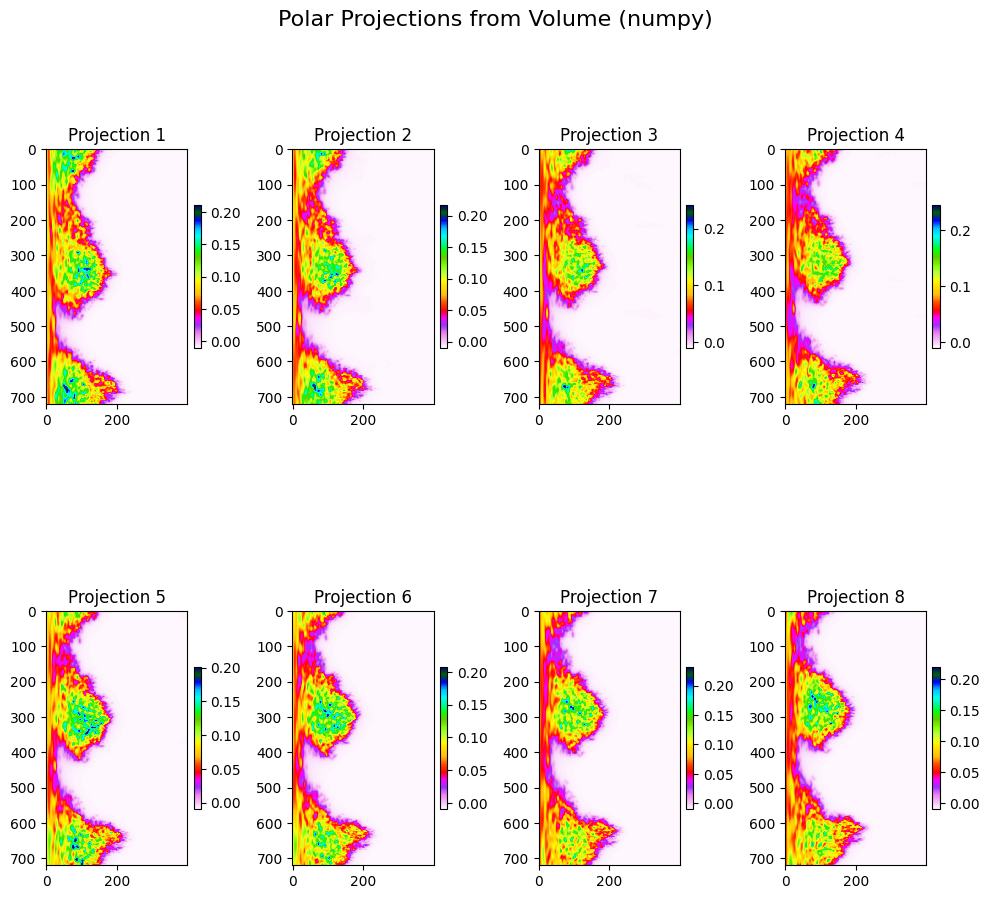

In [11]:
# Plot the first 16 projections
fig, axes = plt.subplots(2, 4, figsize=(10, 10))
for i, ax in enumerate(axes.ravel()):
    im = ax.imshow(projections[i], cmap="gist_ncar_r", interpolation="none")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f"Projection {i + 1}")

fig.suptitle("Polar Projections from Volume (numpy)", fontsize=16)
plt.tight_layout()
plt.show()

### GPU (torch / cuCIM) results

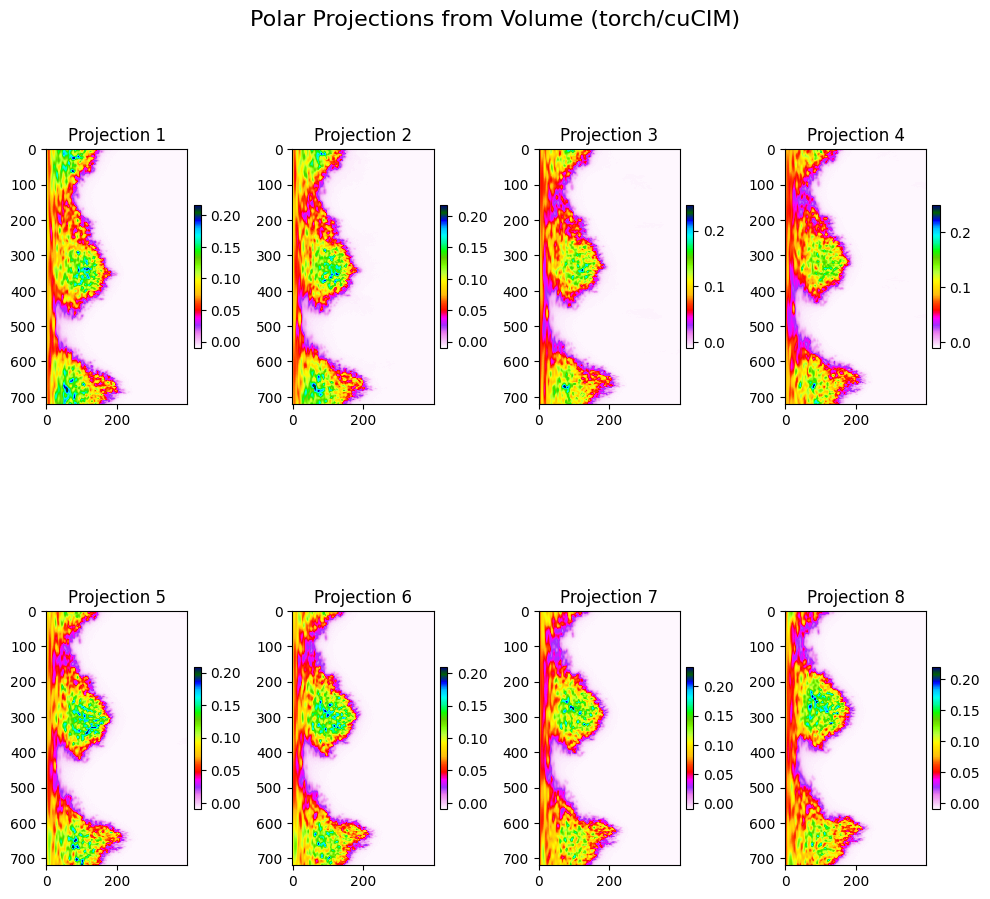

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(10, 10))
for i, ax in enumerate(axes.ravel()):
    im = ax.imshow(
        projections_gpu.cpu().numpy()[i], cmap="gist_ncar_r", interpolation="none"
    )
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f"Projection {i + 1}")

fig.suptitle("Polar Projections from Volume (torch/cuCIM)", fontsize=16)
plt.tight_layout()
plt.show()

### Difference between the two

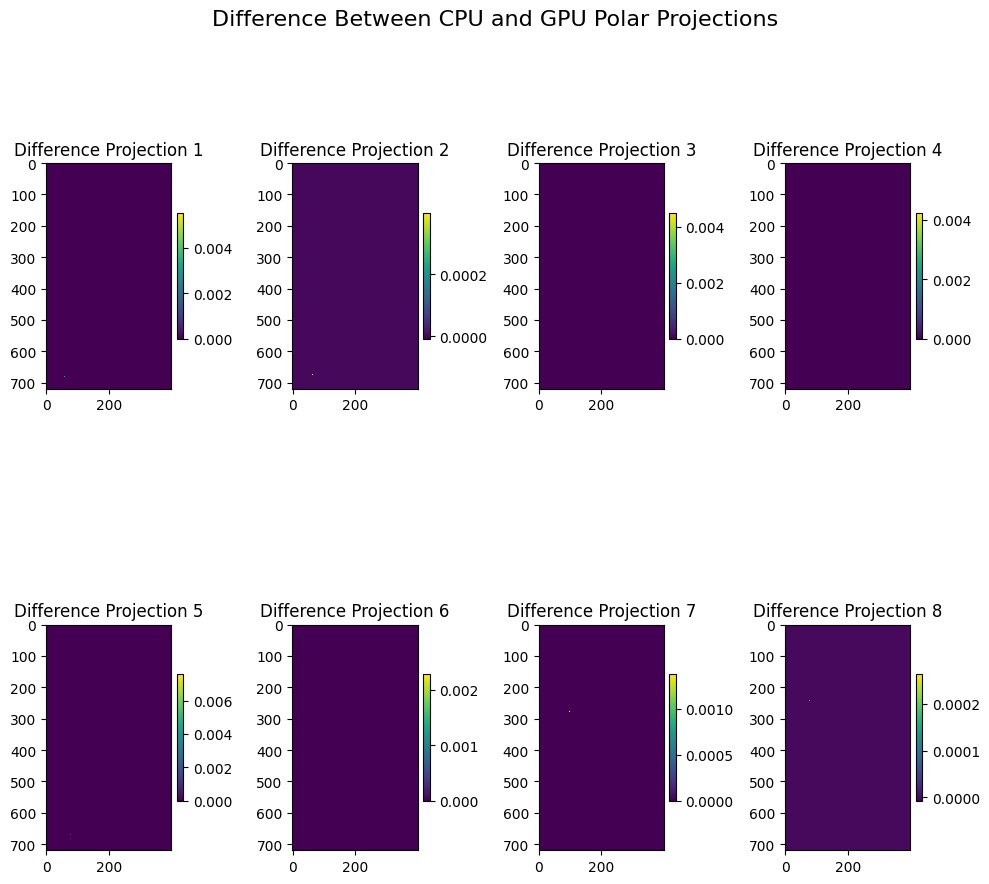

In [13]:
# Plot the difference between the two sets of polar projections
fig, axes = plt.subplots(2, 4, figsize=(10, 10))
for i, ax in enumerate(axes.ravel()):
    diff = projections_gpu.cpu().numpy()[i] - projections[i]
    im = ax.imshow(diff, interpolation="none")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f"Difference Projection {i + 1}")

fig.suptitle("Difference Between CPU and GPU Polar Projections", fontsize=16)
plt.tight_layout()
plt.show()

## Demonstrating inverse projection recovery

By applying the warp transformation in the opposite direction, we can recover the projections in a cartesian coordinate system.

In [14]:
inverse_projections = warp_offset_polar_inverse(
    projections,
    height=volume.shape[0],
    width=volume.shape[1],
    radius=radius,
    center=(volume.shape[1] // 2, volume.shape[2] // 2),
)

inverse_projections.shape

(37, 256, 256)

In [15]:
inverse_projections_gpu = warp_offset_polar_inverse(
    projections_gpu,
    height=volume.shape[0],
    width=volume.shape[1],
    radius=radius,
    center=(volume.shape[1] // 2, volume.shape[2] // 2),
)

inverse_projections_gpu.shape, inverse_projections_gpu.device

(torch.Size([37, 256, 256]), device(type='cuda', index=0))

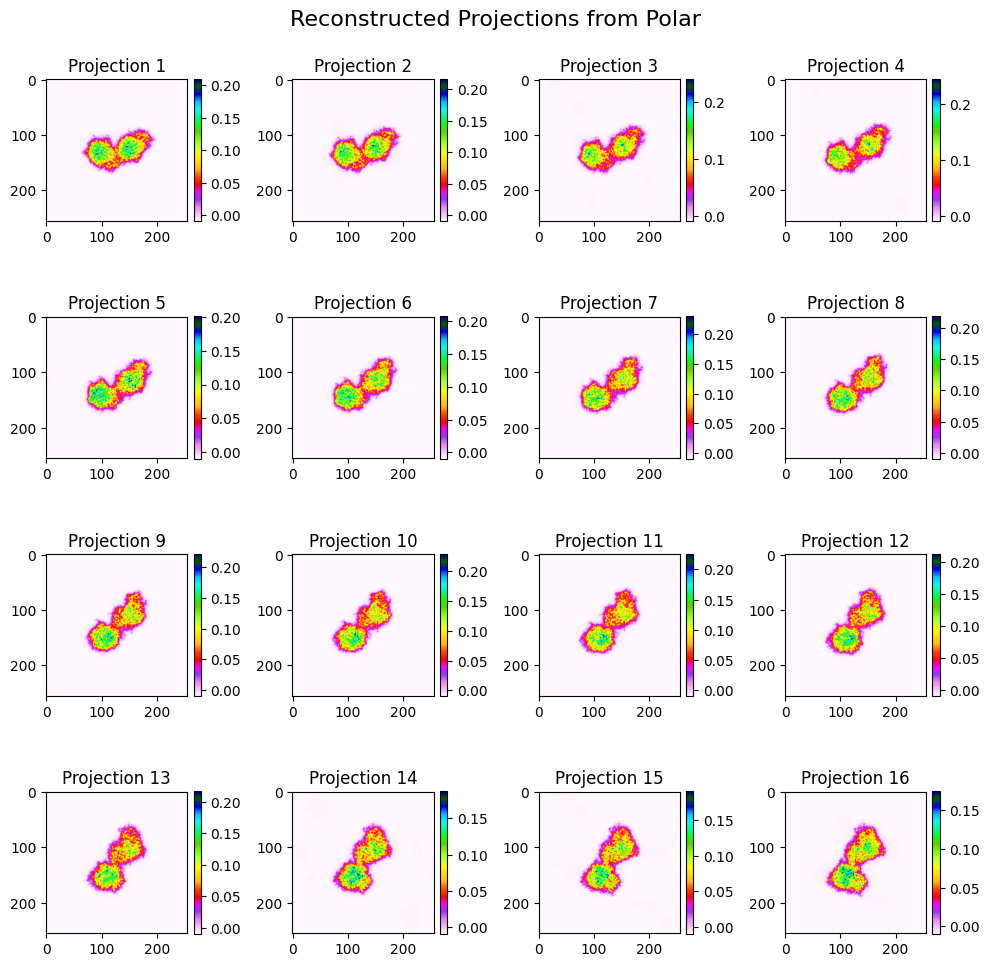

In [16]:
# Plot the first 16 reinverted projections
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.ravel()):
    im = ax.imshow(inverse_projections[i], cmap="gist_ncar_r")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f"Projection {i + 1}")
fig.suptitle("Reconstructed Projections from Polar", fontsize=16)
plt.tight_layout()
plt.show()

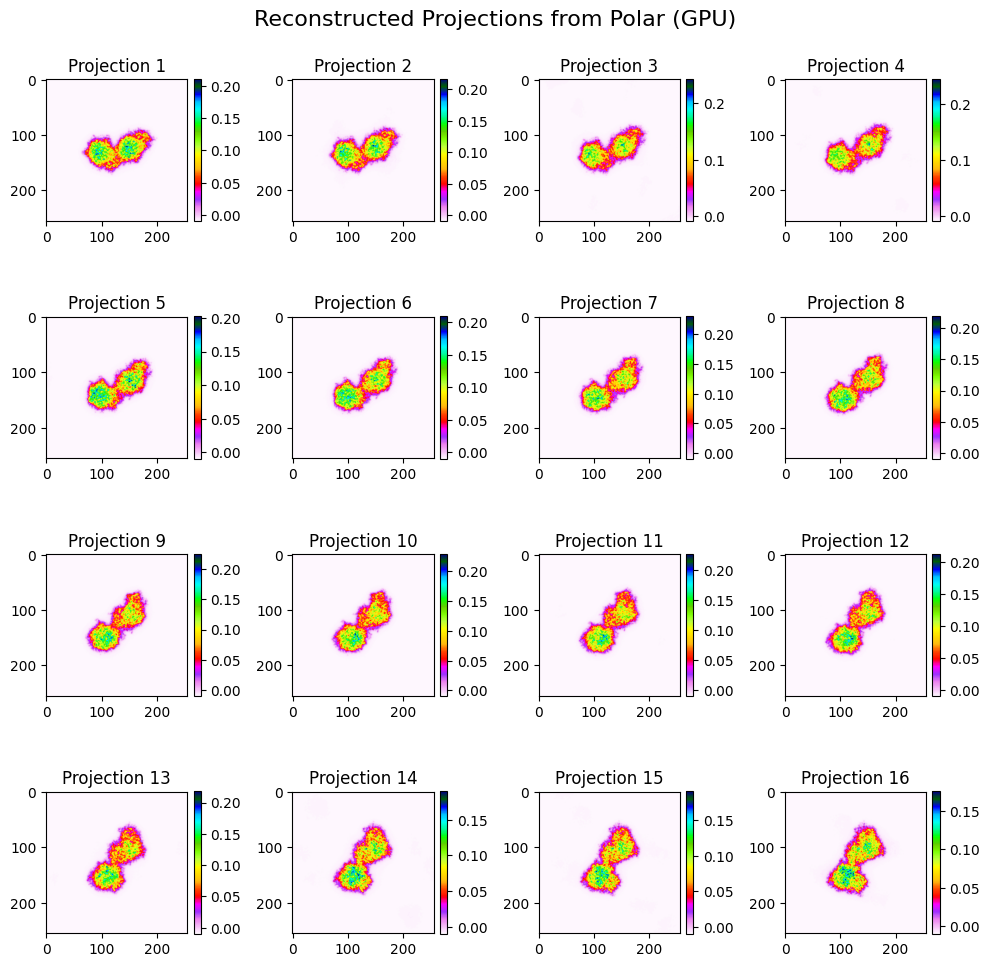

In [17]:
# Plot the first 16 reinverted projections (on GPU)
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.ravel()):
    im = ax.imshow(inverse_projections_gpu[i].cpu().numpy(), cmap="gist_ncar_r")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f"Projection {i + 1}")
fig.suptitle("Reconstructed Projections from Polar (GPU)", fontsize=16)
plt.tight_layout()
plt.show()

### Difference between this and ground-truth projections

In [18]:
# Plot the differences of the first 16 reinverted projections with their ground-truth
ground_truth_projections = project_3d_to_2d(
    volume=torch.from_numpy(volume), rotation_matrices=torch.from_numpy(rot_matrix)
)
ground_truth_projections.shape

torch.Size([37, 256, 256])

/tmp/ipykernel_2019504/3083868078.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  diff = ground_truth_projections - inverse_projections


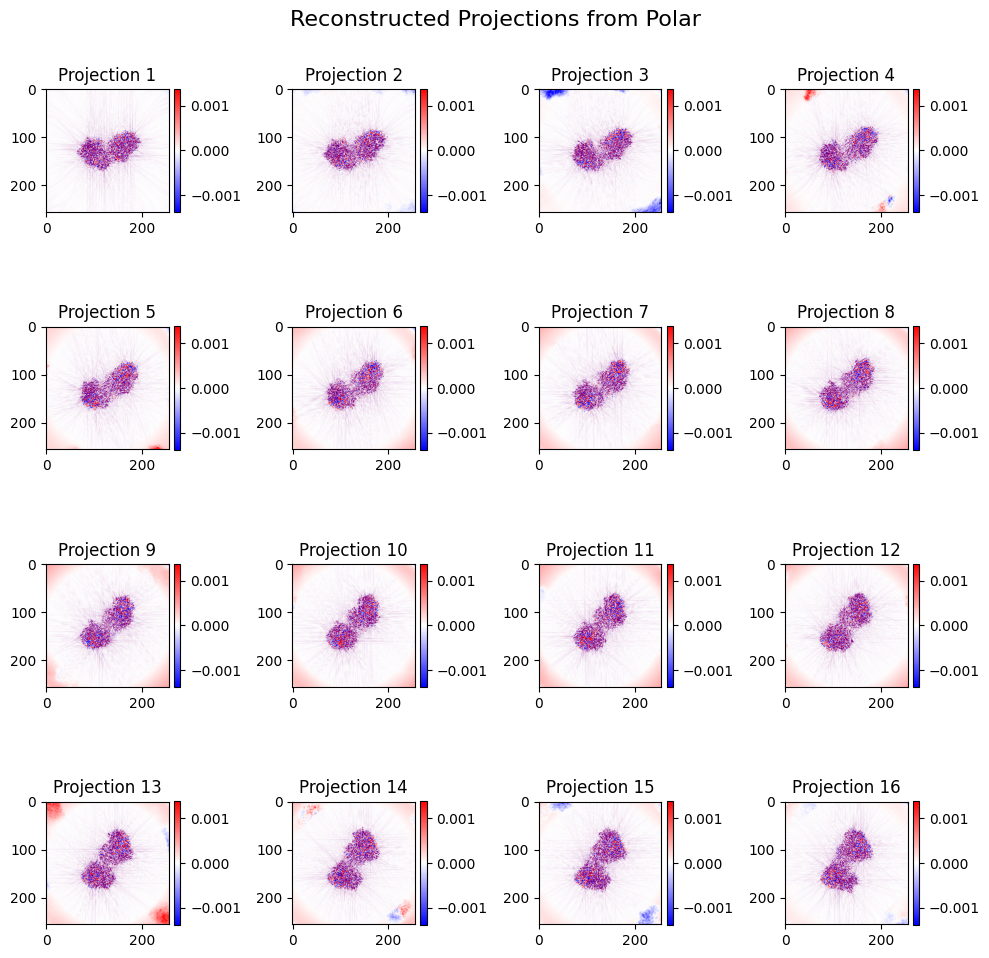

In [19]:
diff = ground_truth_projections - inverse_projections
max_diff = diff.abs().max() * 0.1

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.ravel()):
    im = ax.imshow(diff[i], cmap="bwr", vmin=-max_diff, vmax=max_diff)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f"Projection {i + 1}")
fig.suptitle("Reconstructed Projections from Polar", fontsize=16)
plt.tight_layout()
plt.show()